Connected to learn-unlimited-ocr (3.12.3) (Python 3.12.3)

In [ ]:
import datetime
import json
import logging
import sys
from dataclasses import dataclass, replace
from functools import partial
from pathlib import Path
from typing import Any, Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import Image as IPImage, Markdown, display
from PIL import Image
from transformers import AutoModel, AutoTokenizer

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger(__name__)


def _clean_tokens(tokens: List[str]) -> List[str]:
    """Replace Unicode fullwidth bars that some fonts cannot render."""
    return [t.replace("\uff5c", "|") for t in tokens]


class Showcase:
    """Save intermediate artifacts, log summaries, and display them inline.

    Parameters
    ----------
    out_dir : Path
        Required. Notebook output directory; artifacts are written to
        ``out_dir / "intermediate"``.
    logger : logging.Logger
        Required. Logger used for artifact summaries.
    """

    def __init__(self, out_dir: Path, logger: logging.Logger):
        """Initialize the showcase helper.

        Parameters
        ----------
        out_dir : Path
            Required. Notebook output directory.
        logger : logging.Logger
            Required. Logger used for artifact summaries.
        """
        self.logger = logger
        self.dir = Path(out_dir) / "intermediate"
        self.dir.mkdir(parents=True, exist_ok=True)

    def _save(self, name: str, writer: Callable[[Path], None]) -> Path:
        """Write an artifact and assert it is non-empty.

        Parameters
        ----------
        name : str
            Required. File name inside the intermediate directory.
        writer : Callable[[Path], None]
            Required. Function that writes the artifact to the given path.

        Returns
        -------
        Path
            Path to the written artifact.
        """
        path = self.dir / name
        writer(path)
        assert path.exists() and path.stat().st_size > 0, f"Empty artifact: {path}"
        self.logger.info("[Showcase] Saved %s (%d bytes)", path, path.stat().st_size)
        return path

    def log_summary(self, name: str, obj: Any) -> None:
        """Log a shape/dtype/length summary for an intermediate object.

        Parameters
        ----------
        name : str
            Required. Human-readable label for the object.
        obj : Any
            Required. Object to summarize.
        """
        if torch.is_tensor(obj):
            self.logger.info(
                "[Showcase] %s: tensor shape=%s dtype=%s",
                name,
                tuple(obj.shape),
                obj.dtype,
            )
        elif isinstance(obj, np.ndarray):
            self.logger.info(
                "[Showcase] %s: ndarray shape=%s dtype=%s",
                name,
                obj.shape,
                obj.dtype,
            )
        elif isinstance(obj, Image.Image):
            self.logger.info(
                "[Showcase] %s: PIL image size=%s mode=%s",
                name,
                obj.size,
                obj.mode,
            )
        elif isinstance(obj, (list, tuple, str)):
            self.logger.info(
                "[Showcase] %s: %s len=%d", name, type(obj).__name__, len(obj)
            )
        else:
            self.logger.info("[Showcase] %s: %s", name, type(obj).__name__)

    def save_image(self, image: Image.Image, name: str, inline: bool = True) -> Path:
        """Save a PIL image, log its size, and display it inline.

        Parameters
        ----------
        image : Image.Image
            Required. Image to save.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved image.
        """
        self.log_summary(name, image)
        path = self._save(name, lambda p: image.save(p))
        if inline:
            display(IPImage(filename=str(path)))
        return path

    def save_tensor_image(
        self, tensor: torch.Tensor, name: str, inline: bool = True
    ) -> Path:
        """Save a normalized CHW float tensor in [-1, 1] as an image.

        Parameters
        ----------
        tensor : torch.Tensor
            Required. Image tensor of shape [3, H, W] normalized to [-1, 1].
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved image.
        """
        self.log_summary(name, tensor)
        arr = tensor.detach().float().cpu()
        arr = ((arr + 1.0) / 2.0).clamp(0, 1)
        img = Image.fromarray((arr.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        path = self._save(name, lambda p: img.save(p))
        if inline:
            display(IPImage(filename=str(path)))
        return path

    def save_text(
        self,
        text: str,
        name: str,
        preview_chars: int = 1500,
        inline: bool = True,
    ) -> Path:
        """Save text, log its length, and display a fenced preview.

        Parameters
        ----------
        text : str
            Required. Text to save.
        name : str
            Required. Artifact file name.
        preview_chars : int
            Optional. Number of characters shown inline. Defaults to 1500.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved text file.
        """
        self.log_summary(name, text)
        path = self._save(name, lambda p: p.write_text(text, encoding="utf-8"))
        if inline:
            preview = text[:preview_chars]
            if len(text) > preview_chars:
                preview += f"\n... [{len(text) - preview_chars} more chars]"
            display(Markdown(f"```text\n{preview}\n```"))
        return path

    def save_json(
        self, obj: Any, name: str, inline: bool = True, max_lines: int = 40
    ) -> Path:
        """Save an object as JSON and display a pretty preview.

        Parameters
        ----------
        obj : Any
            Required. JSON-serializable object.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.
        max_lines : int
            Optional. Number of JSON lines shown inline. Defaults to 40.

        Returns
        -------
        Path
            Path to the saved JSON file.
        """
        payload = json.dumps(obj, indent=2, default=str)
        path = self._save(name, lambda p: p.write_text(payload, encoding="utf-8"))
        self.logger.info("[Showcase] %s: %d bytes of JSON", name, len(payload))
        if inline:
            lines = payload.splitlines()
            preview = "\n".join(lines[:max_lines])
            if len(lines) > max_lines:
                preview += f"\n... [{len(lines) - max_lines} more lines]"
            display(Markdown(f"```json\n{preview}\n```"))
        return path

    def save_table(self, df: pd.DataFrame, name: str, inline: bool = True) -> Path:
        """Save a dataframe as CSV, log its shape, and display it inline.

        Parameters
        ----------
        df : pd.DataFrame
            Required. Dataframe to save.
        name : str
            Required. Artifact file name.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved CSV file.
        """
        self.logger.info(
            "[Showcase] %s: DataFrame shape=%s columns=%s",
            name,
            df.shape,
            list(df.columns),
        )
        path = self._save(name, lambda p: df.to_csv(p, index=False))
        if inline:
            display(df)
        return path

    def save_figure(
        self, fig: plt.Figure, name: str, dpi: int = 300, inline: bool = True
    ) -> Path:
        """Save a matplotlib figure, display it inline, and close it.

        Parameters
        ----------
        fig : plt.Figure
            Required. Figure to save.
        name : str
            Required. Artifact file name.
        dpi : int
            Optional. Save resolution. Defaults to 300.
        inline : bool
            Optional. Whether to display inline. Defaults to True.

        Returns
        -------
        Path
            Path to the saved figure.
        """
        path = self._save(name, lambda p: fig.savefig(p, dpi=dpi, bbox_inches="tight"))
        if inline:
            display(IPImage(filename=str(path)))
        plt.close(fig)
        return path


@dataclass(frozen=True)
class Config:
    """Paths and hyperparameters for the Unlimited-OCR MoE inspection.

    Parameters
    ----------
    model_name : str
        Required. Hugging Face model identifier.
    out_dir : Path
        Required. Directory for all generated artifacts.
    sample_text : str
        Required. Short text used to drive a forward pass.
    target_moe_layer : int
        Required. Layer whose gate score distribution is plotted.
    num_experts : int
        Required. Number of routed experts in each MoE layer.
    top_k : int
        Required. Number of experts selected per token.
    dtype : torch.dtype | None
        Optional. Selected torch dtype for the model. Defaults to None.
    """

    model_name: str
    out_dir: Path
    sample_text: str
    target_moe_layer: int
    num_experts: int
    top_k: int
    dtype: torch.dtype | None = None

    def replace(self, **kwargs: object) -> "Config":
        """Return a new Config with the given fields replaced."""
        return replace(self, **kwargs)


TODAY = datetime.datetime.now().strftime("%Y-%m-%d")
CONFIG = Config(
    model_name="baidu/Unlimited-OCR",
    out_dir=Path(f"outputs/{TODAY}/000-unlimited-ocr-demo/001-moe-inspection"),
    sample_text="The quick brown fox jumps over the lazy dog.",
    target_moe_layer=1,
    num_experts=64,
    top_k=6,
)
CONFIG.out_dir.mkdir(parents=True, exist_ok=True)
_moe_file_handler = logging.FileHandler(CONFIG.out_dir / "run.log", mode="w")
_moe_file_handler.setFormatter(logging.Formatter("%(message)s"))
logging.getLogger().addHandler(_moe_file_handler)
showcase = Showcase(CONFIG.out_dir, logger)
logger.info("Inputs: CONFIG=%s", CONFIG)
assert CONFIG.out_dir.exists(), "Output directory was not created"

Inputs: CONFIG=Config(model_name='baidu/Unlimited-OCR', out_dir=PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection'), sample_text='The quick brown fox jumps over the lazy dog.', target_moe_layer=1, num_experts=64, top_k=6, dtype=None)


 ## Check Environment
 Verify CUDA availability and pick the best dtype for the current GPU.

In [ ]:
class EnvironmentChecker:
    """Check GPU availability and select the inference dtype.

    Parameters
    ----------
    config : Config
        Required. Global configuration; updated with the selected dtype.
    """

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def check(self) -> torch.dtype:
        """Assert CUDA is available and return the selected dtype.

        Returns
        -------
        torch.dtype
            bfloat16 if supported, otherwise float16.
        """
        assert torch.cuda.is_available(), "CUDA unavailable"
        gpu_name = torch.cuda.get_device_name(0)
        use_bf16 = torch.cuda.is_bf16_supported()
        dtype = torch.bfloat16 if use_bf16 else torch.float16
        logger.info("[EnvironmentChecker] GPU: %s", gpu_name)
        logger.info("[EnvironmentChecker] dtype: %s", dtype)
        return dtype


env_checker = EnvironmentChecker(CONFIG)
CONFIG = CONFIG.replace(dtype=env_checker.check())
logger.info("Outputs: CONFIG.dtype=%s", CONFIG.dtype)

[EnvironmentChecker] GPU: NVIDIA GeForce RTX 3090
[EnvironmentChecker] dtype: torch.bfloat16
Outputs: CONFIG.dtype=torch.bfloat16


 ## Load Model
 Load the Unlimited-OCR tokenizer and model onto the GPU.

In [ ]:
class ModelLoader:
    """Load the Unlimited-OCR model and tokenizer.

    Parameters
    ----------
    config : Config
        Required. Global configuration with model_name and dtype.
    """

    def __init__(self, config: Config):
        """Initialize with global config.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        """
        self.config = config

    def load(self) -> Tuple[AutoTokenizer, AutoModel]:
        """Download and load the model.

        Returns
        -------
        Tuple[AutoTokenizer, AutoModel]
            Tokenizer and model ready for inference.
        """
        logger.info("[ModelLoader] Loading %s ...", self.config.model_name)
        tokenizer = AutoTokenizer.from_pretrained(
            self.config.model_name, trust_remote_code=True
        )
        model = AutoModel.from_pretrained(
            self.config.model_name,
            trust_remote_code=True,
            use_safetensors=True,
            torch_dtype=self.config.dtype,
        )
        model = model.eval().cuda()
        logger.info("[ModelLoader] Model loaded")
        return tokenizer, model


model_loader = ModelLoader(CONFIG)
tokenizer, model = model_loader.load()
logger.info(
    "Outputs: tokenizer=%s model=%s",
    type(tokenizer).__name__,
    type(model).__name__,
)
inner_model = model.model
assert hasattr(inner_model, "layers"), "model.model has no layers"
assert len(inner_model.layers) == 12, "Expected 12 layers"

[ModelLoader] Loading baidu/Unlimited-OCR ...
`torch_dtype` is deprecated! Use `dtype` instead!
Some weights of UnlimitedOCRForCausalLM were not initialized from the model checkpoint at baidu/Unlimited-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[ModelLoader] Model loaded
Outputs: tokenizer=LlamaTokenizerFast model=UnlimitedOCRForCausalLM


 ## Architecture Summary
 Print actual model facts and inspect the gate module for one MoE layer.

In [ ]:
class ArchitectureSummary:
    """Summarize the Unlimited-OCR MoE architecture from the loaded model.

    Parameters
    ----------
    model : AutoModel
        Required. Loaded model.
    """

    def __init__(self, model: AutoModel):
        """Initialize with the loaded model.

        Parameters
        ----------
        model : AutoModel
            Required. Loaded model.
        """
        self.model = model
        self.inner = model.model

    def summarize(self) -> Dict[str, Any]:
        """Collect and log architecture facts.

        Returns
        -------
        Dict[str, Any]
            Architecture facts.
        """
        num_layers = len(self.inner.layers)
        dense_layers: List[int] = []
        moe_layers: List[int] = []

        cfg = self.model.config
        n_routed_experts = getattr(cfg, "n_routed_experts", None)
        num_experts_per_tok = getattr(cfg, "num_experts_per_tok", None)
        topk_method = getattr(cfg, "topk_method", None)
        hidden_size = getattr(cfg, "hidden_size", None)
        first_k_dense_replace = getattr(cfg, "first_k_dense_replace", None)

        for idx, layer in enumerate(self.inner.layers):
            mlp = layer.mlp
            mlp_type = type(mlp).__name__
            if mlp_type == "DeepseekV2MLP":
                dense_layers.append(idx)
            elif mlp_type == "DeepseekV2MoE":
                moe_layers.append(idx)

        logger.info("[ArchitectureSummary] Total layers: %s", num_layers)
        logger.info("[ArchitectureSummary] Dense layers: %s", dense_layers)
        logger.info("[ArchitectureSummary] MoE layers: %s", moe_layers)
        logger.info("[ArchitectureSummary] n_routed_experts: %s", n_routed_experts)
        logger.info(
            "[ArchitectureSummary] num_experts_per_tok: %s",
            num_experts_per_tok,
        )
        logger.info("[ArchitectureSummary] topk_method: %s", topk_method)
        logger.info("[ArchitectureSummary] hidden_size: %s", hidden_size)
        logger.info(
            "[ArchitectureSummary] first_k_dense_replace: %s",
            first_k_dense_replace,
        )
        logger.info(
            "[ArchitectureSummary] Gate module: %s",
            self.inner.layers[1].mlp.gate,
        )
        logger.info(
            "[ArchitectureSummary] Gate weight shape: %s",
            self.inner.layers[1].mlp.gate.weight.shape,
        )

        return {
            "num_layers": num_layers,
            "dense_layers": dense_layers,
            "moe_layers": moe_layers,
            "n_routed_experts": n_routed_experts,
            "num_experts_per_tok": num_experts_per_tok,
            "topk_method": topk_method,
            "hidden_size": hidden_size,
            "first_k_dense_replace": first_k_dense_replace,
        }


arch_summary = ArchitectureSummary(model)
arch_facts = arch_summary.summarize()
assert arch_facts["num_layers"] == 12
assert arch_facts["dense_layers"] == [0]
assert arch_facts["moe_layers"] == list(range(1, 12))
assert arch_facts["n_routed_experts"] == 64
assert arch_facts["num_experts_per_tok"] == 6

[ArchitectureSummary] Total layers: 12
[ArchitectureSummary] Dense layers: [0]
[ArchitectureSummary] MoE layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[ArchitectureSummary] n_routed_experts: 64
[ArchitectureSummary] num_experts_per_tok: 6
[ArchitectureSummary] topk_method: greedy
[ArchitectureSummary] hidden_size: 1280
[ArchitectureSummary] first_k_dense_replace: 1
[ArchitectureSummary] Gate module: MoEGate()
[ArchitectureSummary] Gate weight shape: torch.Size([64, 1280])


 ## Capture MoE Routing
 Register forward hooks on every MoEGate module and run a short forward pass.

In [ ]:
class MoEInspector:
    """Capture MoE routing decisions during a forward pass.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    model : AutoModel
        Required. Loaded model.
    """

    def __init__(self, config: Config, tokenizer: AutoTokenizer, model: AutoModel):
        """Initialize with config, tokenizer, and model.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        model : AutoModel
            Required. Loaded model.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.model = model
        self.records: Dict[int, Dict[str, Any]] = {}

    def _record_hook(
        self,
        layer_idx: int,
        _module: torch.nn.Module,
        _input: Tuple[torch.Tensor, ...],
        output: Tuple[torch.Tensor, ...],
    ) -> Tuple[torch.Tensor, ...]:
        """Store routing output from a MoEGate forward pass.

        Parameters
        ----------
        layer_idx : int
            Required. Layer index for this gate.
        _module : torch.nn.Module
            Required. Gate module.
        _input : Tuple[torch.Tensor, ...]
            Required. Gate inputs.
        output : Tuple[torch.Tensor, ...]
            Required. Gate outputs (topk_idx, topk_weight, aux_loss).

        Returns
        -------
        Tuple[torch.Tensor, ...]
            Unmodified output.
        """
        topk_idx, topk_weight, aux_loss = output
        self.records[layer_idx] = {
            "topk_idx": topk_idx.detach().cpu(),
            "topk_weight": topk_weight.detach().cpu(),
            "aux_loss": (
                float(aux_loss)
                if torch.is_tensor(aux_loss)
                else (float(aux_loss) if isinstance(aux_loss, (int, float)) else None)
            ),
        }
        logger.info(
            "[MoEInspector] Layer %s routing: topk_idx=%s topk_weight=%s",
            layer_idx,
            tuple(topk_idx.shape),
            tuple(topk_weight.shape),
        )
        return output

    def inspect(self) -> Dict[int, Dict[str, Any]]:
        """Run a forward pass and capture MoE routing.

        Returns
        -------
        Dict[int, Dict[str, Any]]
            Mapping from layer index to routing tensors.
        """
        self.records = {}
        inner = self.model.model
        handles: List[Any] = []

        for idx, layer in enumerate(inner.layers):
            if not hasattr(layer.mlp, "gate"):
                continue
            gate = layer.mlp.gate
            if type(gate).__name__ == "MoEGate":
                handle = gate.register_forward_hook(partial(self._record_hook, idx))
                handles.append(handle)

        inputs = self.tokenizer(self.config.sample_text, return_tensors="pt")
        input_ids = inputs["input_ids"].cuda()
        with torch.no_grad():
            _ = inner(input_ids=input_ids)

        for handle in handles:
            handle.remove()

        logger.info("[MoEInspector] Captured routing for %s layers", len(self.records))
        return self.records

    @property
    def tokens(self) -> List[str]:
        """Return token strings for the sample text.

        Returns
        -------
        List[str]
            Token strings.
        """
        inputs = self.tokenizer(self.config.sample_text, return_tensors="pt")
        return self.tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])


moe_inspector = MoEInspector(CONFIG, tokenizer, model)
routing_records = moe_inspector.inspect()
assert len(routing_records) == 11, "Expected 11 MoE layers"
for layer_idx, rec in routing_records.items():
    assert rec["topk_idx"].shape[1] == CONFIG.top_k
    assert rec["topk_weight"].shape[1] == CONFIG.top_k
logger.info("Outputs: tokens=%s", moe_inspector.tokens)

past_key_values should not be None in from_legacy_cache()
[MoEInspector] Layer 1 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 2 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 3 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 4 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 5 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 6 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 7 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 8 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 9 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 10 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Layer 11 routing: topk_idx=(11, 6) topk_weight=(11, 6)
[MoEInspector] Captured routing for 11 layers
Outputs: tokens=['<｜begin▁of▁sentence｜>', 'The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']


 ## Showcase: Input Tokens
 Save the tokenized sample input (ids and tokens), log its shape, and display it.

In [ ]:
class InputTokenShowcase:
    """Save and display the tokenized sample input.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, config: Config, tokenizer: AutoTokenizer, showcase: Showcase):
        """Initialize with config, tokenizer, and showcase helper.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.showcase = showcase

    def run(self) -> Dict[str, Any]:
        """Tokenize the sample text and save ids plus tokens.

        Returns
        -------
        Dict[str, Any]
            Saved token payload.
        """
        inputs = self.tokenizer(self.config.sample_text, return_tensors="pt")
        input_ids = inputs["input_ids"]
        self.showcase.log_summary("input_ids", input_ids)
        payload = {
            "sample_text": self.config.sample_text,
            "input_ids_shape": list(input_ids.shape),
            "input_ids": input_ids[0].tolist(),
            "tokens": self.tokenizer.convert_ids_to_tokens(input_ids[0]),
        }
        self.showcase.save_json(payload, "00_input_tokens.json")
        logger.info("[InputTokenShowcase] input_ids shape=%s", tuple(input_ids.shape))
        return payload


input_token_showcase = InputTokenShowcase(CONFIG, tokenizer, showcase)
input_tokens = input_token_showcase.run()
logger.info("Outputs: input_tokens keys=%s", list(input_tokens.keys()))
assert len(input_tokens["input_ids"]) == len(input_tokens["tokens"])

[Showcase] input_ids: tensor shape=(1, 11) dtype=torch.int64
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/00_input_tokens.json (468 bytes)
[Showcase] 00_input_tokens.json: 468 bytes of JSON


```json
{
  "sample_text": "The quick brown fox jumps over the lazy dog.",
  "input_ids_shape": [
    1,
    11
  ],
  "input_ids": [
    0,
    671,
    4787,
    13769,
    46012,
    54994,
    1060,
    270,
    41638,
    6397,
    16
  ],
  "tokens": [
    "<\uff5cbegin\u2581of\u2581sentence\uff5c>",
    "The",
    "\u0120quick",
    "\u0120brown",
    "\u0120fox",
    "\u0120jumps",
    "\u0120over",
    "\u0120the",
    "\u0120lazy",
    "\u0120dog",
    "."
  ]
}
```

[InputTokenShowcase] input_ids shape=(1, 11)
Outputs: input_tokens keys=['sample_text', 'input_ids_shape', 'input_ids', 'tokens']


 ## Showcase: Top-K Routing Sample
 Save the captured top-k expert indices and weights for the target layer as a
 table, and log the tensor shapes for every layer.

In [ ]:
class RoutingSampleShowcase:
    """Save and display captured top-k routing for the target MoE layer.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    inspector : MoEInspector
        Required. Inspector with captured routing records.
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, config: Config, inspector: MoEInspector, showcase: Showcase):
        """Initialize with config, inspector, and showcase helper.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        inspector : MoEInspector
            Required. Inspector with captured routing records.
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.config = config
        self.inspector = inspector
        self.showcase = showcase

    def run(self) -> pd.DataFrame:
        """Save routing shapes for all layers and a table for the target layer.

        Returns
        -------
        pd.DataFrame
            Per-token experts and weights for the target layer.
        """
        shapes = {
            str(layer_idx): {
                "topk_idx_shape": list(rec["topk_idx"].shape),
                "topk_weight_shape": list(rec["topk_weight"].shape),
                "aux_loss": rec["aux_loss"],
            }
            for layer_idx, rec in sorted(self.inspector.records.items())
        }
        self.showcase.save_json(shapes, "01_routing_shapes_all_layers.json")

        rec = self.inspector.records[self.config.target_moe_layer]
        self.showcase.log_summary("topk_idx", rec["topk_idx"])
        self.showcase.log_summary("topk_weight", rec["topk_weight"])
        tokens = self.inspector.tokens
        rows = [
            {
                "position": pos,
                "token": token,
                "experts": rec["topk_idx"][pos].tolist(),
                "weights": [round(w, 4) for w in rec["topk_weight"][pos].tolist()],
            }
            for pos, token in enumerate(tokens)
        ]
        df = pd.DataFrame(rows)
        self.showcase.save_table(
            df, f"01_routing_table_layer{self.config.target_moe_layer}.csv"
        )
        return df


routing_sample_showcase = RoutingSampleShowcase(CONFIG, moe_inspector, showcase)
routing_sample_df = routing_sample_showcase.run()
logger.info("Outputs: routing_sample_df.shape=%s", routing_sample_df.shape)
assert len(routing_sample_df) == len(moe_inspector.tokens)

[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/01_routing_shapes_all_layers.json (1500 bytes)
[Showcase] 01_routing_shapes_all_layers.json: 1500 bytes of JSON


```json
{
  "1": {
    "topk_idx_shape": [
      11,
      6
    ],
    "topk_weight_shape": [
      11,
      6
    ],
    "aux_loss": null
  },
  "2": {
    "topk_idx_shape": [
      11,
      6
    ],
    "topk_weight_shape": [
      11,
      6
    ],
    "aux_loss": null
  },
  "3": {
    "topk_idx_shape": [
      11,
      6
    ],
    "topk_weight_shape": [
      11,
      6
    ],
    "aux_loss": null
  },
  "4": {
    "topk_idx_shape": [
      11,
      6
    ],
    "topk_weight_shape": [
... [83 more lines]
```

[Showcase] topk_idx: tensor shape=(11, 6) dtype=torch.int64
[Showcase] topk_weight: tensor shape=(11, 6) dtype=torch.float32
[Showcase] 01_routing_table_layer1.csv: DataFrame shape=(11, 4) columns=['position', 'token', 'experts', 'weights']
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/01_routing_table_layer1.csv (985 bytes)


,position,token,experts,weights
0,0,<｜begin▁of▁sentence｜>,"[0, 35, 46, 49, 62, 14]","[0.0097, 0.0213, 0.8058, 0.009, 0.0074, 0.0074]"
1,1,The,"[6, 44, 46, 55, 62, 42]","[0.041, 0.0304, 0.4505, 0.0379, 0.0988, 0.0253]"
2,2,Ġquick,"[17, 22, 44, 46, 59, 34]","[0.8965, 0.0061, 0.0108, 0.0192, 0.0145, 0.0061]"
3,3,Ġbrown,"[1, 34, 44, 56, 59, 2]","[0.1361, 0.0789, 0.1838, 0.0366, 0.1955, 0.0329]"
4,4,Ġfox,"[2, 7, 21, 31, 56, 39]","[0.1819, 0.0831, 0.0346, 0.0579, 0.1157, 0.0339]"
5,5,Ġjumps,"[4, 5, 20, 27, 51, 7]","[0.0674, 0.0683, 0.0671, 0.0592, 0.1906, 0.0451]"
6,6,Ġover,"[2, 38, 41, 51, 52, 10]","[0.0454, 0.1457, 0.1358, 0.2066, 0.1003, 0.0236]"
7,7,Ġthe,"[15, 46, 52, 58, 62, 29]","[0.0441, 0.051, 0.0606, 0.0592, 0.1856, 0.0414]"
8,8,Ġlazy,"[1, 17, 34, 56, 59, 44]","[0.0109, 0.886, 0.007, 0.0049, 0.0194, 0.0041]"
9,9,Ġdog,"[2, 7, 30, 31, 56, 11]","[0.0566, 0.0843, 0.0564, 0.0751, 0.1063, 0.0455]"


Outputs: routing_sample_df.shape=(11, 4)


 ## Routing Table
 Print a human-readable table of selected experts and weights per token.

In [ ]:
class RoutingTable:
    """Format captured routing decisions as human-readable tables.

    Parameters
    ----------
    inspector : MoEInspector
        Required. Inspector with captured routing records.
    """

    def __init__(self, inspector: MoEInspector):
        """Initialize with an inspector.

        Parameters
        ----------
        inspector : MoEInspector
            Required. Inspector with captured routing records.
        """
        self.inspector = inspector

    def print_table(self) -> None:
        """Print a table of selected experts and weights for each MoE layer."""
        tokens = self.inspector.tokens
        for layer_idx, rec in sorted(self.inspector.records.items()):
            topk_idx = rec["topk_idx"]
            topk_weight = rec["topk_weight"]
            rows = []
            for pos, token in enumerate(tokens):
                experts = topk_idx[pos].tolist()
                weights = [round(w, 4) for w in topk_weight[pos].tolist()]
                rows.append(
                    {
                        "token": token,
                        "experts": experts,
                        "weights": weights,
                    }
                )
            df = pd.DataFrame(rows)
            logger.info("[RoutingTable] Layer %s", layer_idx)
            logger.info("\n%s", df.to_string(index=False))
            assert len(df) == len(tokens), "Table row count mismatch"
            assert all(
                len(row["experts"]) == CONFIG.top_k for row in rows
            ), "Wrong expert count"


routing_table = RoutingTable(moe_inspector)
routing_table.print_table()

[RoutingTable] Layer 1

                token                  experts                                          weights
<｜begin▁of▁sentence｜>  [0, 35, 46, 49, 62, 14]  [0.0097, 0.0213, 0.8058, 0.009, 0.0074, 0.0074]
                  The  [6, 44, 46, 55, 62, 42]  [0.041, 0.0304, 0.4505, 0.0379, 0.0988, 0.0253]
               Ġquick [17, 22, 44, 46, 59, 34] [0.8965, 0.0061, 0.0108, 0.0192, 0.0145, 0.0061]
               Ġbrown   [1, 34, 44, 56, 59, 2] [0.1361, 0.0789, 0.1838, 0.0366, 0.1955, 0.0329]
                 Ġfox   [2, 7, 21, 31, 56, 39] [0.1819, 0.0831, 0.0346, 0.0579, 0.1157, 0.0339]
               Ġjumps    [4, 5, 20, 27, 51, 7] [0.0674, 0.0683, 0.0671, 0.0592, 0.1906, 0.0451]
                Ġover  [2, 38, 41, 51, 52, 10] [0.0454, 0.1457, 0.1358, 0.2066, 0.1003, 0.0236]
                 Ġthe [15, 46, 52, 58, 62, 29]  [0.0441, 0.051, 0.0606, 0.0592, 0.1856, 0.0414]
                Ġlazy  [1, 17, 34, 56, 59, 44]   [0.0109, 0.886, 0.007, 0.0049, 0.0194, 0.0041]
                

 ## Gate Score Distribution
 Capture hidden states entering the target gate and plot the full softmax score
 distribution over all 64 experts for each token.

In [ ]:
class GateScorePlot:
    """Plot the full gate score distribution for one MoE layer.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    tokenizer : AutoTokenizer
        Required. Loaded tokenizer.
    model : AutoModel
        Required. Loaded model.
    """

    def __init__(self, config: Config, tokenizer: AutoTokenizer, model: AutoModel):
        """Initialize with config, tokenizer, and model.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        tokenizer : AutoTokenizer
            Required. Loaded tokenizer.
        model : AutoModel
            Required. Loaded model.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.model = model
        self._hidden_state: torch.Tensor | None = None
        self.gate = model.model.layers[config.target_moe_layer].mlp.gate

    def _capture_hook(
        self,
        _module: torch.nn.Module,
        _input: Tuple[torch.Tensor, ...],
    ) -> None:
        """Store the hidden state entering the gate.

        Parameters
        ----------
        _module : torch.nn.Module
            Required. Gate module.
        _input : Tuple[torch.Tensor, ...]
            Required. Hidden state entering the gate.
        """
        self._hidden_state = _input[0].detach().cpu()

    def compute_scores(self) -> np.ndarray:
        """Compute softmax gate scores for each token.

        Returns
        -------
        np.ndarray
            Array of shape [seq_len, num_experts].
        """
        handle = self.gate.register_forward_pre_hook(self._capture_hook)
        inputs = self.tokenizer(self.config.sample_text, return_tensors="pt")
        input_ids = inputs["input_ids"].cuda()
        with torch.no_grad():
            _ = self.model.model(input_ids=input_ids)
        handle.remove()

        assert self._hidden_state is not None, "Hidden state not captured"
        hidden = self._hidden_state.float().squeeze(0)
        logits = F.linear(hidden, self.gate.weight.detach().cpu().float())
        scores = F.softmax(logits, dim=-1).numpy().astype(np.float32)
        return scores

    def plot(self, scores: np.ndarray) -> Path:
        """Save a heatmap of gate scores.

        Parameters
        ----------
        scores : np.ndarray
            Required. Softmax gate scores.

        Returns
        -------
        Path
            Path to saved PNG.
        """
        tokens = _clean_tokens(
            self.tokenizer.convert_ids_to_tokens(
                self.tokenizer(self.config.sample_text, return_tensors="pt")[
                    "input_ids"
                ][0]
            )
        )
        plt.figure(figsize=(14, max(4, len(tokens) * 0.4)))
        sns.heatmap(
            scores,
            xticklabels=range(self.config.num_experts),
            yticklabels=tokens,
            cmap="viridis",
            cbar_kws={"label": "gate score"},
        )
        plt.xlabel("expert")
        plt.ylabel("token")
        plt.title(f"Gate score distribution for layer {self.config.target_moe_layer}")
        out_path = self.config.out_dir / "01_gate_scores.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()
        logger.info("[GateScorePlot] Saved %s", out_path)
        return out_path


gate_score_plot = GateScorePlot(CONFIG, tokenizer, model)
gate_scores = gate_score_plot.compute_scores()
gate_score_path = gate_score_plot.plot(gate_scores)
logger.info("Outputs: gate_scores.shape=%s path=%s", gate_scores.shape, gate_score_path)
assert gate_scores.shape == (len(moe_inspector.tokens), CONFIG.num_experts)
assert np.allclose(gate_scores.sum(axis=1), 1.0, atol=1e-4)
assert gate_score_path.exists()

[GateScorePlot] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/01_gate_scores.png
Outputs: gate_scores.shape=(11, 64) path=outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/01_gate_scores.png


 ## Showcase: Hidden State and Gate Score Matrix
 Save the hidden state entering the target gate (shape, stats, heatmap) and
 the full gate score matrix as a CSV with a displayed sample.

[Showcase] hidden_state: tensor shape=(1, 11, 1280) dtype=torch.bfloat16
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/02_hidden_state_summary.json (194 bytes)
[Showcase] 02_hidden_state_summary.json: 194 bytes of JSON


```json
{
  "hidden_state_shape": [
    1,
    11,
    1280
  ],
  "hidden_state_dtype": "torch.bfloat16",
  "mean": 0.00469115749001503,
  "std": 0.5465789437294006,
  "min": -4.59375,
  "max": 8.875
}
```

[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/02_hidden_state_heatmap.png (104827 bytes)


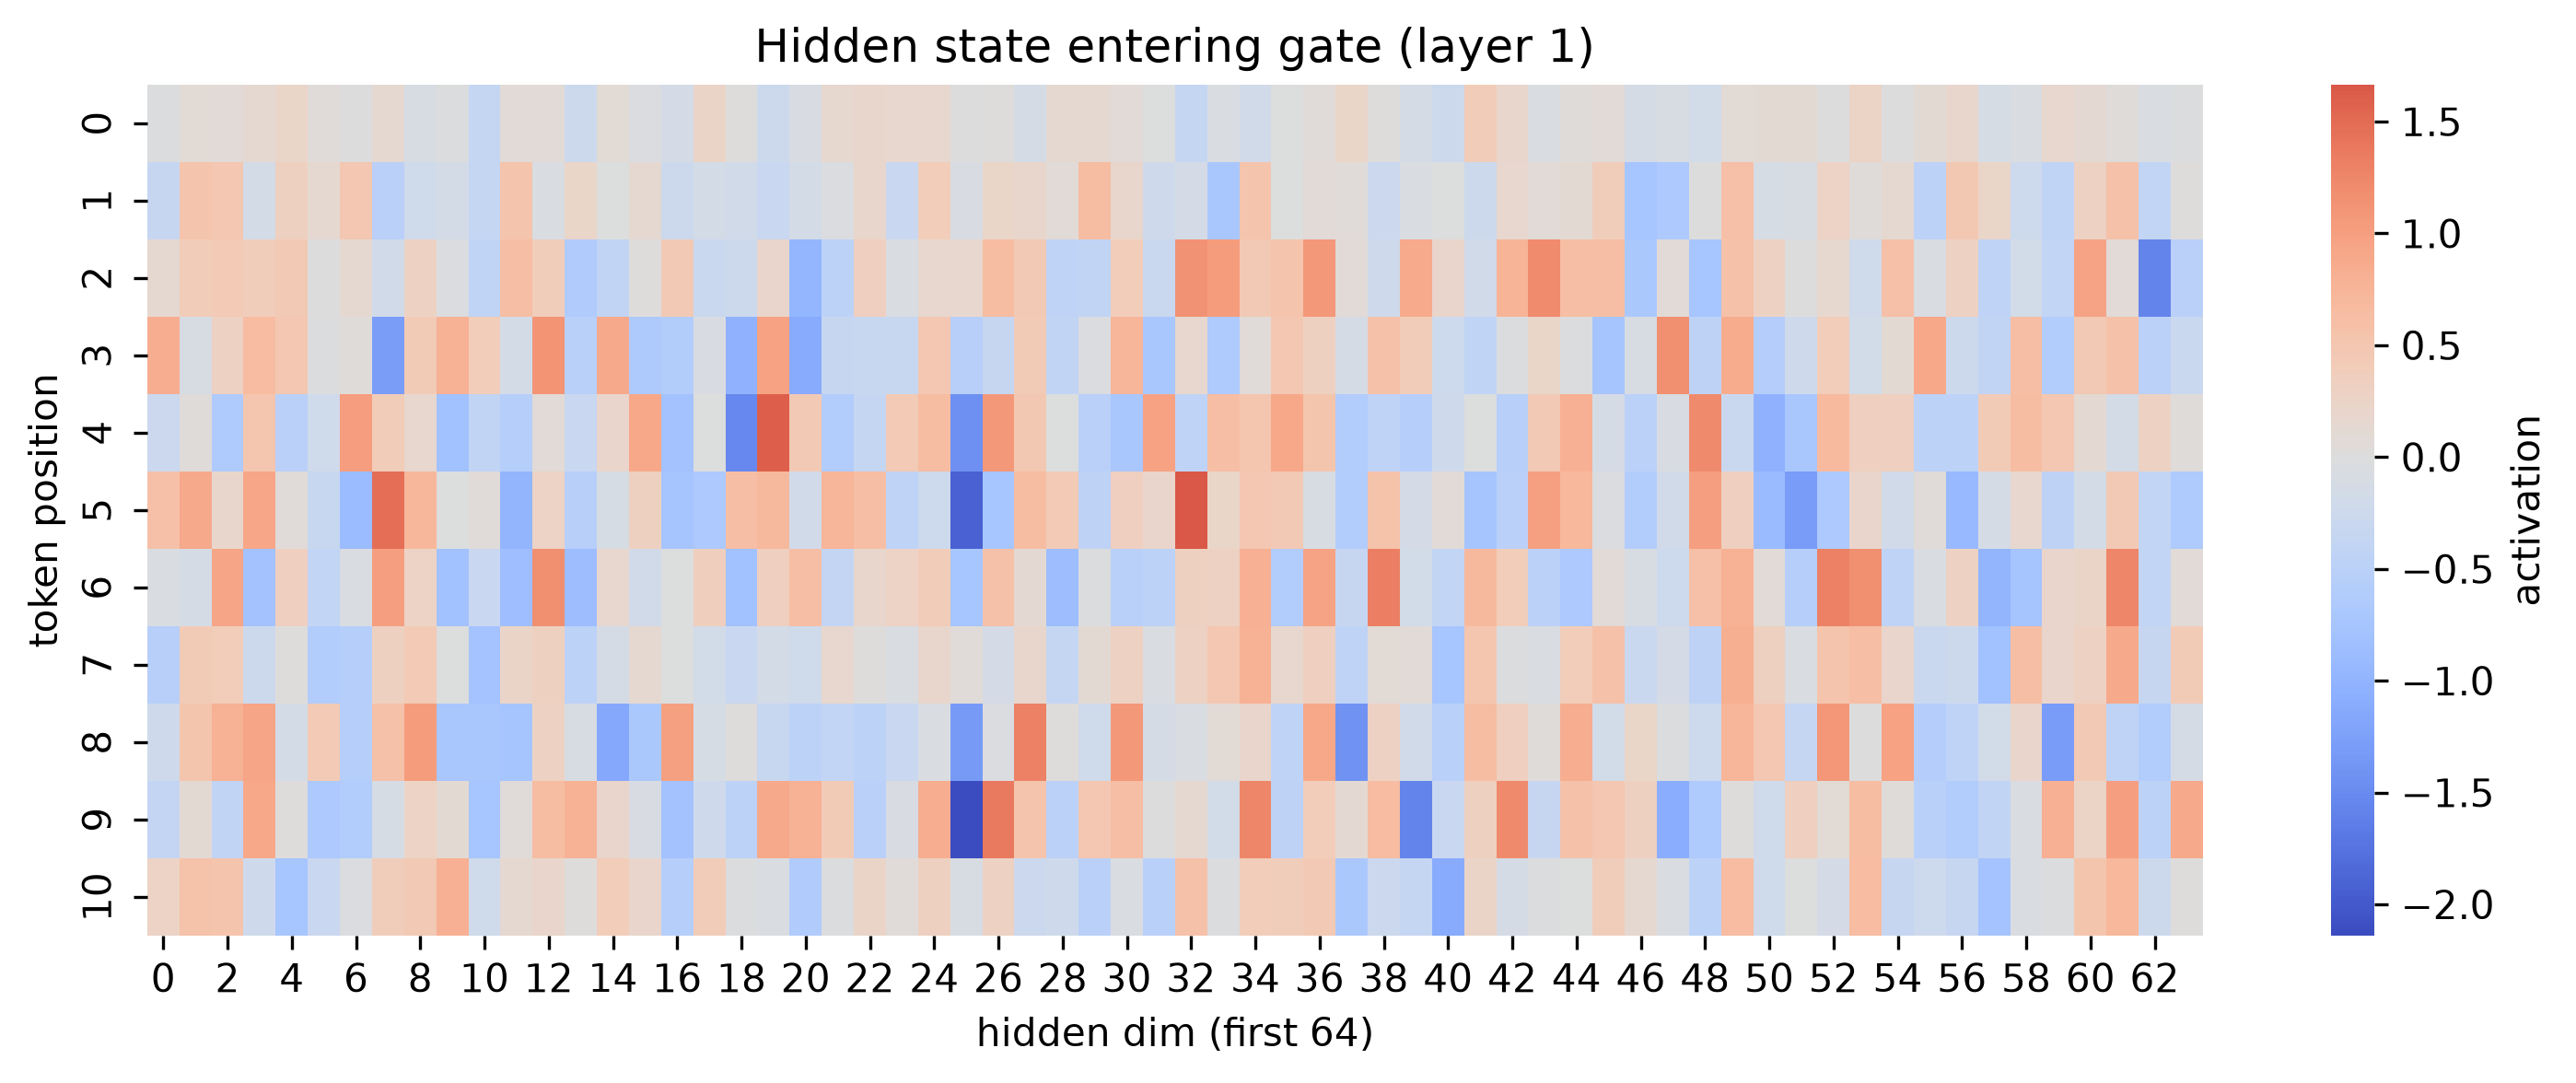

[Showcase] gate_scores: ndarray shape=(11, 64) dtype=float32
[Showcase] 02_gate_scores.csv: DataFrame shape=(11, 64) columns=['E0', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63']
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/02_gate_scores.csv (6501 bytes)
[Showcase] 02_gate_scores_top5.csv: DataFrame shape=(11, 3) columns=['token_position', 'top5_experts', 'top5_scores']
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/02_gate_scores_top5.csv (772 bytes)


,token_position,top5_experts,top5_scores
0,0,"[46, 35, 0, 49, 62]","[0.8058, 0.0213, 0.0097, 0.009, 0.0074]"
1,1,"[46, 62, 6, 55, 44]","[0.4505, 0.0988, 0.041, 0.0379, 0.0304]"
2,2,"[17, 46, 59, 44, 22]","[0.8965, 0.0192, 0.0145, 0.0108, 0.0061]"
3,3,"[59, 44, 1, 34, 56]","[0.1955, 0.1838, 0.1361, 0.0789, 0.0366]"
4,4,"[2, 56, 7, 31, 21]","[0.1819, 0.1157, 0.0831, 0.0579, 0.0346]"
5,5,"[51, 5, 4, 20, 27]","[0.1906, 0.0683, 0.0674, 0.0671, 0.0592]"
6,6,"[51, 38, 41, 52, 2]","[0.2066, 0.1457, 0.1358, 0.1003, 0.0454]"
7,7,"[62, 52, 58, 46, 15]","[0.1856, 0.0606, 0.0592, 0.051, 0.0441]"
8,8,"[17, 59, 1, 34, 56]","[0.886, 0.0194, 0.0109, 0.007, 0.0049]"
9,9,"[56, 7, 31, 2, 30]","[0.1063, 0.0843, 0.0751, 0.0566, 0.0564]"


[GateIntermediateShowcase] hidden=(1, 11, 1280) scores=(11, 64)
Outputs: hidden state and gate score intermediates saved


In [ ]:
class GateIntermediateShowcase:
    """Save and display the gate's hidden-state input and score matrix.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    showcase : Showcase
        Required. Shared save/log/display helper.
    """

    def __init__(self, config: Config, showcase: Showcase):
        """Initialize with config and showcase helper.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        showcase : Showcase
            Required. Shared save/log/display helper.
        """
        self.config = config
        self.showcase = showcase

    def run(self, hidden_state: torch.Tensor, scores: np.ndarray) -> None:
        """Save hidden-state summary/heatmap and the gate score matrix.

        Parameters
        ----------
        hidden_state : torch.Tensor
            Required. Hidden state entering the gate, shape [1, seq, hidden].
        scores : np.ndarray
            Required. Softmax gate scores, shape [seq, num_experts].
        """
        self.showcase.log_summary("hidden_state", hidden_state)
        hidden = hidden_state.float().squeeze(0)
        summary = {
            "hidden_state_shape": list(hidden_state.shape),
            "hidden_state_dtype": str(hidden_state.dtype),
            "mean": float(hidden.mean()),
            "std": float(hidden.std()),
            "min": float(hidden.min()),
            "max": float(hidden.max()),
        }
        self.showcase.save_json(summary, "02_hidden_state_summary.json")

        dims = min(64, hidden.shape[1])
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.heatmap(
            hidden[:, :dims].numpy(),
            cmap="coolwarm",
            center=0,
            ax=ax,
            cbar_kws={"label": "activation"},
        )
        ax.set_xlabel(f"hidden dim (first {dims})")
        ax.set_ylabel("token position")
        ax.set_title(
            f"Hidden state entering gate (layer {self.config.target_moe_layer})"
        )
        self.showcase.save_figure(fig, "02_hidden_state_heatmap.png")

        self.showcase.log_summary("gate_scores", scores)
        score_df = pd.DataFrame(
            scores, columns=[f"E{i}" for i in range(self.config.num_experts)]
        )
        self.showcase.save_table(score_df.round(6), "02_gate_scores.csv", inline=False)
        top5 = pd.DataFrame(
            [
                {
                    "token_position": pos,
                    "top5_experts": np.argsort(row)[-5:][::-1].tolist(),
                    "top5_scores": [
                        round(float(row[i]), 4) for i in np.argsort(row)[-5:][::-1]
                    ],
                }
                for pos, row in enumerate(scores)
            ]
        )
        self.showcase.save_table(top5, "02_gate_scores_top5.csv")
        logger.info(
            "[GateIntermediateShowcase] hidden=%s scores=%s",
            tuple(hidden_state.shape),
            scores.shape,
        )


gate_intermediate_showcase = GateIntermediateShowcase(CONFIG, showcase)
gate_intermediate_showcase.run(gate_score_plot._hidden_state, gate_scores)
logger.info("Outputs: hidden state and gate score intermediates saved")

 ## Top-K Selection Matrix
 Build a sparse binary matrix showing which experts are selected for each token
 across all MoE layers.

In [ ]:
class TopKSelectionPlot:
    """Build a sparse binary matrix of top-k expert selections.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    inspector : MoEInspector
        Required. Inspector with captured routing records.
    """

    def __init__(self, config: Config, inspector: MoEInspector):
        """Initialize with config and inspector.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        inspector : MoEInspector
            Required. Inspector with captured routing records.
        """
        self.config = config
        self.inspector = inspector

    def build_matrix(self) -> np.ndarray:
        """Build a binary [tokens, experts] selection matrix.

        Returns
        -------
        np.ndarray
            Binary matrix of shape [seq_len, num_experts].
        """
        tokens = self.inspector.tokens
        matrix = np.zeros((len(tokens), self.config.num_experts), dtype=int)
        for rec in self.inspector.records.values():
            topk_idx = rec["topk_idx"].numpy()
            for pos in range(topk_idx.shape[0]):
                matrix[pos, topk_idx[pos]] = 1
        return matrix

    def plot(self, matrix: np.ndarray) -> Path:
        """Save a heatmap of the binary selection matrix.

        Parameters
        ----------
        matrix : np.ndarray
            Required. Binary selection matrix.

        Returns
        -------
        Path
            Path to saved PNG.
        """
        tokens = _clean_tokens(self.inspector.tokens)
        plt.figure(figsize=(14, max(4, len(tokens) * 0.4)))
        sns.heatmap(
            matrix,
            xticklabels=range(self.config.num_experts),
            yticklabels=tokens,
            cmap="Greys",
            cbar=False,
        )
        plt.xlabel("expert")
        plt.ylabel("token")
        plt.title("Top-k expert selection across all MoE layers")
        out_path = self.config.out_dir / "02_topk_selections.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()
        logger.info("[TopKSelectionPlot] Saved %s", out_path)
        return out_path


topk_plot = TopKSelectionPlot(CONFIG, moe_inspector)
topk_matrix = topk_plot.build_matrix()
topk_path = topk_plot.plot(topk_matrix)
logger.info("Outputs: topk_matrix.shape=%s path=%s", topk_matrix.shape, topk_path)
assert topk_matrix.shape == (len(moe_inspector.tokens), CONFIG.num_experts)
assert set(np.unique(topk_matrix)).issubset({0, 1})
assert topk_path.exists()

# Showcase: save the binary selection matrix as a table.
showcase.log_summary("topk_matrix", topk_matrix)
topk_df = pd.DataFrame(
    topk_matrix,
    index=[f"pos_{i}" for i in range(topk_matrix.shape[0])],
    columns=[f"E{i}" for i in range(CONFIG.num_experts)],
)
topk_matrix_path = showcase.dir / "03_topk_selection_matrix.csv"
topk_df.to_csv(topk_matrix_path)
assert topk_matrix_path.exists() and topk_matrix_path.stat().st_size > 0
logger.info("[Showcase] Saved %s", topk_matrix_path)

[TopKSelectionPlot] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/02_topk_selections.png
Outputs: topk_matrix.shape=(11, 64) path=outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/02_topk_selections.png
[Showcase] topk_matrix: ndarray shape=(11, 64) dtype=int64
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/03_topk_selection_matrix.csv


 ## Expert Load per Layer
 Plot the total routing weight per expert for each MoE layer.

In [ ]:
class ExpertLoadPlot:
    """Plot the total routing weight per expert for each MoE layer.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    inspector : MoEInspector
        Required. Inspector with captured routing records.
    """

    def __init__(self, config: Config, inspector: MoEInspector):
        """Initialize with config and inspector.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        inspector : MoEInspector
            Required. Inspector with captured routing records.
        """
        self.config = config
        self.inspector = inspector

    def build_load(self) -> np.ndarray:
        """Compute total routing weight per expert per layer.

        Returns
        -------
        np.ndarray
            Array of shape [num_moe_layers, num_experts].
        """
        moe_layer_indices = sorted(self.inspector.records.keys())
        load = np.zeros((len(moe_layer_indices), self.config.num_experts))
        for i, layer_idx in enumerate(moe_layer_indices):
            rec = self.inspector.records[layer_idx]
            topk_idx = rec["topk_idx"].numpy().flatten()
            topk_weight = rec["topk_weight"].numpy().flatten()
            np.add.at(load[i], topk_idx, topk_weight)
        return load

    def plot(self, load: np.ndarray) -> Path:
        """Save a heatmap of expert load per layer.

        Parameters
        ----------
        load : np.ndarray
            Required. Load matrix.

        Returns
        -------
        Path
            Path to saved PNG.
        """
        layer_labels = [str(i) for i in sorted(self.inspector.records.keys())]
        plt.figure(figsize=(14, 6))
        sns.heatmap(
            load,
            xticklabels=range(self.config.num_experts),
            yticklabels=layer_labels,
            cmap="YlOrRd",
            cbar_kws={"label": "total routing weight"},
        )
        plt.xlabel("expert")
        plt.ylabel("MoE layer")
        plt.title("Total routing weight per expert per layer")
        out_path = self.config.out_dir / "03_expert_load.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()
        logger.info("[ExpertLoadPlot] Saved %s", out_path)
        return out_path


expert_load_plot = ExpertLoadPlot(CONFIG, moe_inspector)
expert_load = expert_load_plot.build_load()
expert_load_path = expert_load_plot.plot(expert_load)
logger.info(
    "Outputs: expert_load.shape=%s path=%s", expert_load.shape, expert_load_path
)
assert expert_load.shape == (len(routing_records), CONFIG.num_experts)
assert expert_load_path.exists()

# Showcase: save the per-layer expert load matrix as a table.
showcase.log_summary("expert_load", expert_load)
load_df = pd.DataFrame(
    expert_load.round(4),
    index=[f"layer_{i}" for i in sorted(routing_records.keys())],
    columns=[f"E{i}" for i in range(CONFIG.num_experts)],
)
load_path = showcase.dir / "04_expert_load.csv"
load_df.to_csv(load_path)
assert load_path.exists() and load_path.stat().st_size > 0
logger.info("[Showcase] Saved %s", load_path)

[ExpertLoadPlot] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/03_expert_load.png
Outputs: expert_load.shape=(11, 64) path=outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/03_expert_load.png
[Showcase] expert_load: ndarray shape=(11, 64) dtype=float64
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/04_expert_load.csv


 ## Aggregate Expert Usage
 Aggregate routing weights across all layers and plot usage per expert.

In [ ]:
class AggregateUsagePlot:
    """Plot aggregate routing weight usage per expert across all layers.

    Parameters
    ----------
    config : Config
        Required. Global configuration.
    inspector : MoEInspector
        Required. Inspector with captured routing records.
    """

    def __init__(self, config: Config, inspector: MoEInspector):
        """Initialize with config and inspector.

        Parameters
        ----------
        config : Config
            Required. Global configuration.
        inspector : MoEInspector
            Required. Inspector with captured routing records.
        """
        self.config = config
        self.inspector = inspector

    def build_usage(self) -> pd.DataFrame:
        """Aggregate total routing weight per expert across all layers.

        Returns
        -------
        pd.DataFrame
            DataFrame with expert and usage columns.
        """
        usage = np.zeros(self.config.num_experts)
        for rec in self.inspector.records.values():
            topk_idx = rec["topk_idx"].numpy().flatten()
            topk_weight = rec["topk_weight"].numpy().flatten()
            np.add.at(usage, topk_idx, topk_weight)
        df = pd.DataFrame(
            {
                "expert": range(self.config.num_experts),
                "usage": usage,
                "expert_label": [f"E{i}" for i in range(self.config.num_experts)],
            }
        )
        return df

    def plot(self, df: pd.DataFrame) -> Path:
        """Save a barplot of aggregate expert usage.

        Parameters
        ----------
        df : pd.DataFrame
            Required. Usage dataframe.

        Returns
        -------
        Path
            Path to saved PNG.
        """
        plt.figure(figsize=(14, 6))
        sns.barplot(
            data=df,
            x="expert_label",
            y="usage",
            color="steelblue",
        )
        plt.xlabel("expert")
        plt.ylabel("aggregate routing weight")
        plt.title("Aggregate expert usage across all MoE layers")
        out_path = self.config.out_dir / "04_aggregate_usage.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()
        logger.info("[AggregateUsagePlot] Saved %s", out_path)
        return out_path


aggregate_usage_plot = AggregateUsagePlot(CONFIG, moe_inspector)
aggregate_df = aggregate_usage_plot.build_usage()
aggregate_path = aggregate_usage_plot.plot(aggregate_df)
logger.info("Outputs: aggregate_path=%s", aggregate_path)
assert aggregate_path.exists()

# Showcase: save and display the aggregate usage table.
showcase.save_table(aggregate_df.round(4), "05_aggregate_usage.csv")

[AggregateUsagePlot] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/04_aggregate_usage.png
Outputs: aggregate_path=outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/04_aggregate_usage.png
[Showcase] 05_aggregate_usage.csv: DataFrame shape=(64, 3) columns=['expert', 'usage', 'expert_label']
[Showcase] Saved outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/05_aggregate_usage.csv (892 bytes)


,expert,usage,expert_label
0,0,1.2630,E0
1,1,1.2537,E1
2,2,1.7951,E2
3,3,0.4635,E3
4,4,1.0092,E4
...,...,...,...
59,59,0.9444,E59
60,60,0.4859,E60
61,61,1.2253,E61
62,62,1.1418,E62


PosixPath('outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/05_aggregate_usage.csv')

 ## Final Validation
 Verify that all four expected PNG artifacts were saved.

In [ ]:
for fname in (
    "01_gate_scores.png",
    "02_topk_selections.png",
    "03_expert_load.png",
    "04_aggregate_usage.png",
):
    path = CONFIG.out_dir / fname
    assert path.exists(), f"Missing output: {path}"
    logger.info("[Validation] Found %s", path)
logger.info("[Validation] All four PNGs exist")

for fname in (
    "00_input_tokens.json",
    "01_routing_shapes_all_layers.json",
    f"01_routing_table_layer{CONFIG.target_moe_layer}.csv",
    "02_hidden_state_summary.json",
    "02_hidden_state_heatmap.png",
    "02_gate_scores.csv",
    "02_gate_scores_top5.csv",
    "03_topk_selection_matrix.csv",
    "04_expert_load.csv",
    "05_aggregate_usage.csv",
):
    path = showcase.dir / fname
    assert path.exists() and path.stat().st_size > 0, f"Missing intermediate: {path}"
    logger.info("[Validation] Found intermediate %s", path)
logger.info("[Validation] All intermediate artifacts exist and are non-empty")

[Validation] Found outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/01_gate_scores.png
[Validation] Found outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/02_topk_selections.png
[Validation] Found outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/03_expert_load.png
[Validation] Found outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/04_aggregate_usage.png
[Validation] All four PNGs exist
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/00_input_tokens.json
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/01_routing_shapes_all_layers.json
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/01_routing_table_layer1.csv
[Validation] Found intermediate outputs/2026-07-26/000-unlimited-ocr-demo/001-moe-inspection/intermediate/02_hidden_state_summary.json
[Validation] Found intermed

 ## Cheat Sheet
 Summarize the MoE architecture and routing behavior in plain language.

In [ ]:
logger.info("\nCheat sheet")
logger.info(
    "MoE: each token is routed to a small subset of 64 expert feed-forward networks."
)
logger.info(
    "Dense layer: layers[0].mlp is a DeepseekV2MLP (one FFN used by every token)."
)
logger.info(
    "MoE layers: layers[1..11].mlp are DeepseekV2MoE (64 experts, top-6 per token)."
)
logger.info(
    "Routing module: layer.mlp.gate (type MoEGate) returns topk_idx, topk_weight, aux_loss."
)
logger.info(
    "Gate score distribution: softmax over all 64 experts computed per token in the target layer."
)


Cheat sheet
MoE: each token is routed to a small subset of 64 expert feed-forward networks.
Dense layer: layers[0].mlp is a DeepseekV2MLP (one FFN used by every token).
MoE layers: layers[1..11].mlp are DeepseekV2MoE (64 experts, top-6 per token).
Routing module: layer.mlp.gate (type MoEGate) returns topk_idx, topk_weight, aux_loss.
Gate score distribution: softmax over all 64 experts computed per token in the target layer.


 ## Display Plots
 Render the saved MoE plots inline when running in a notebook.

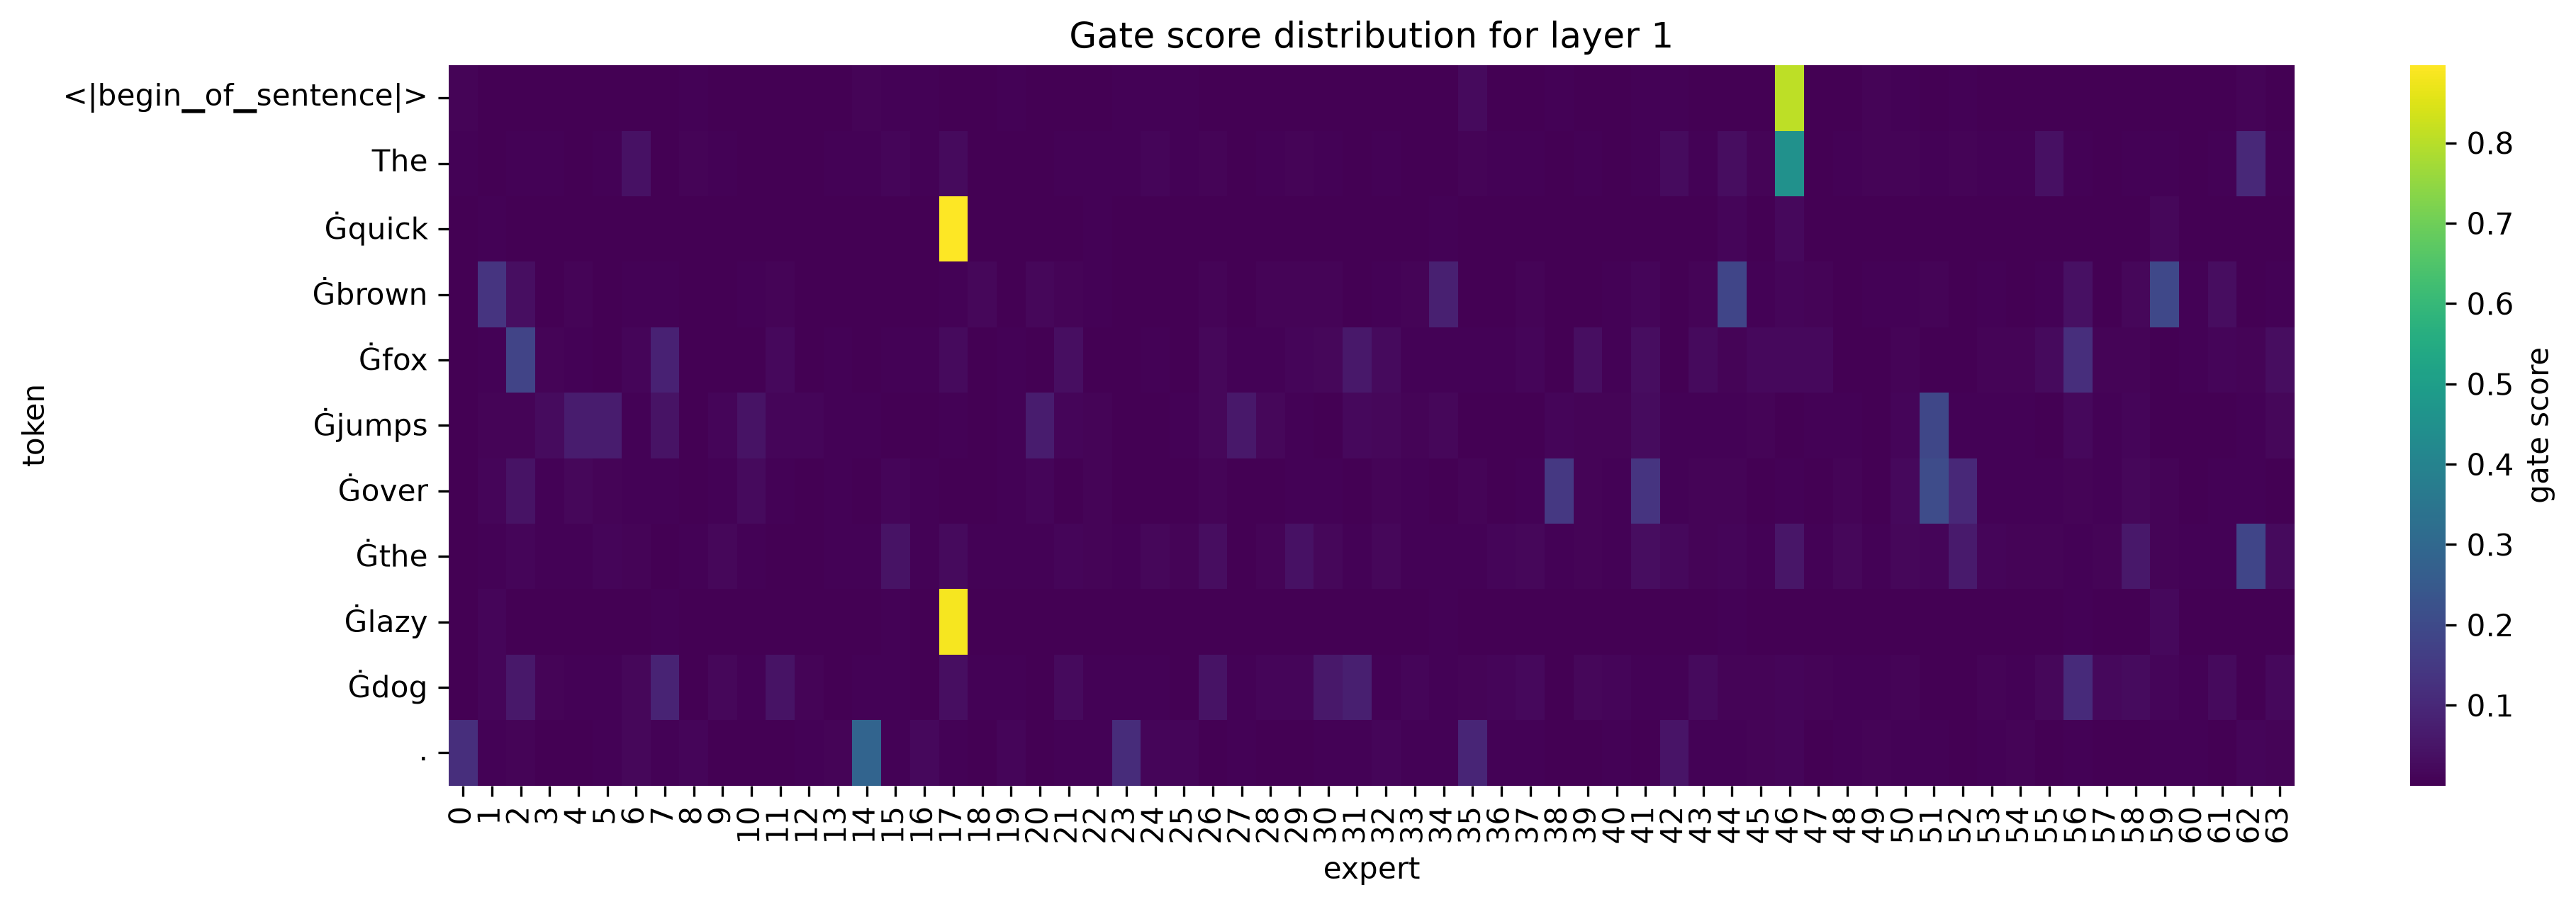

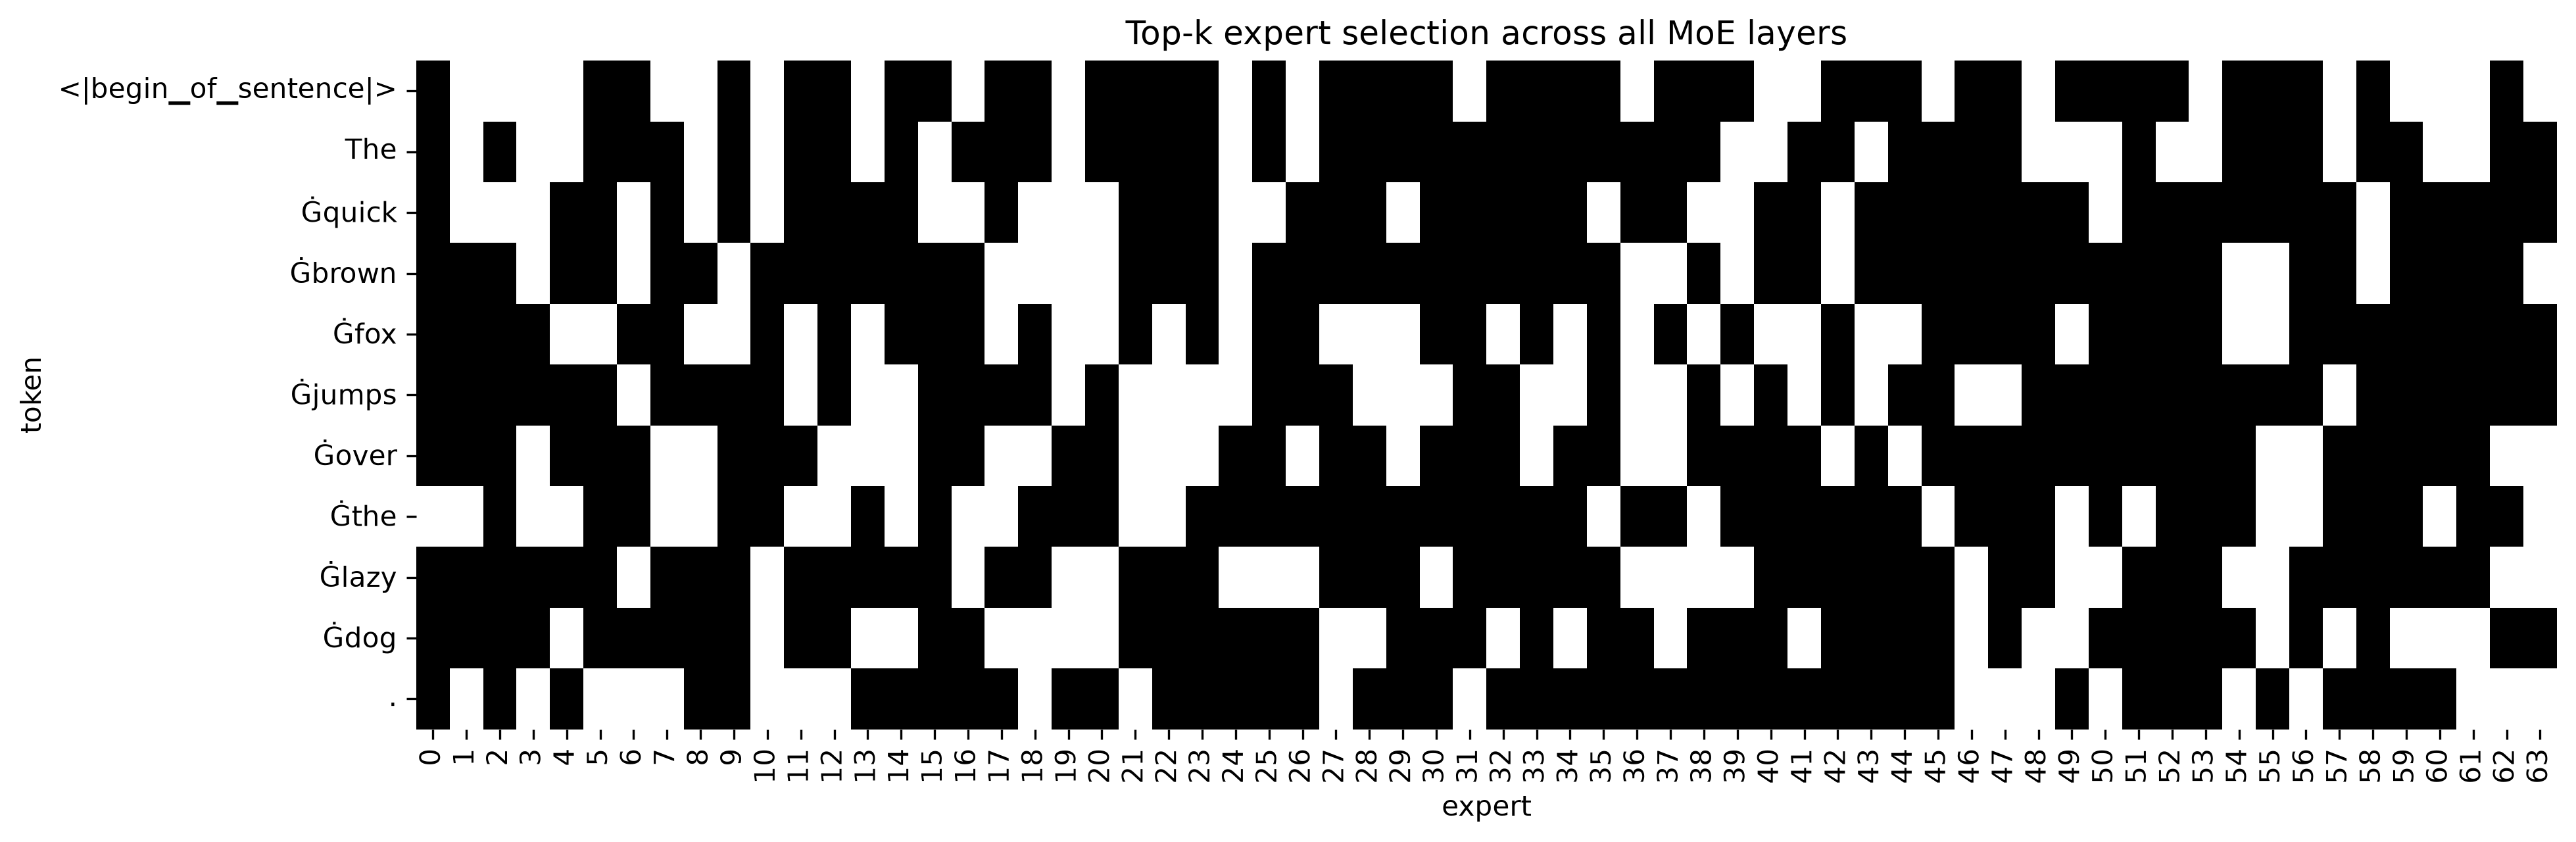

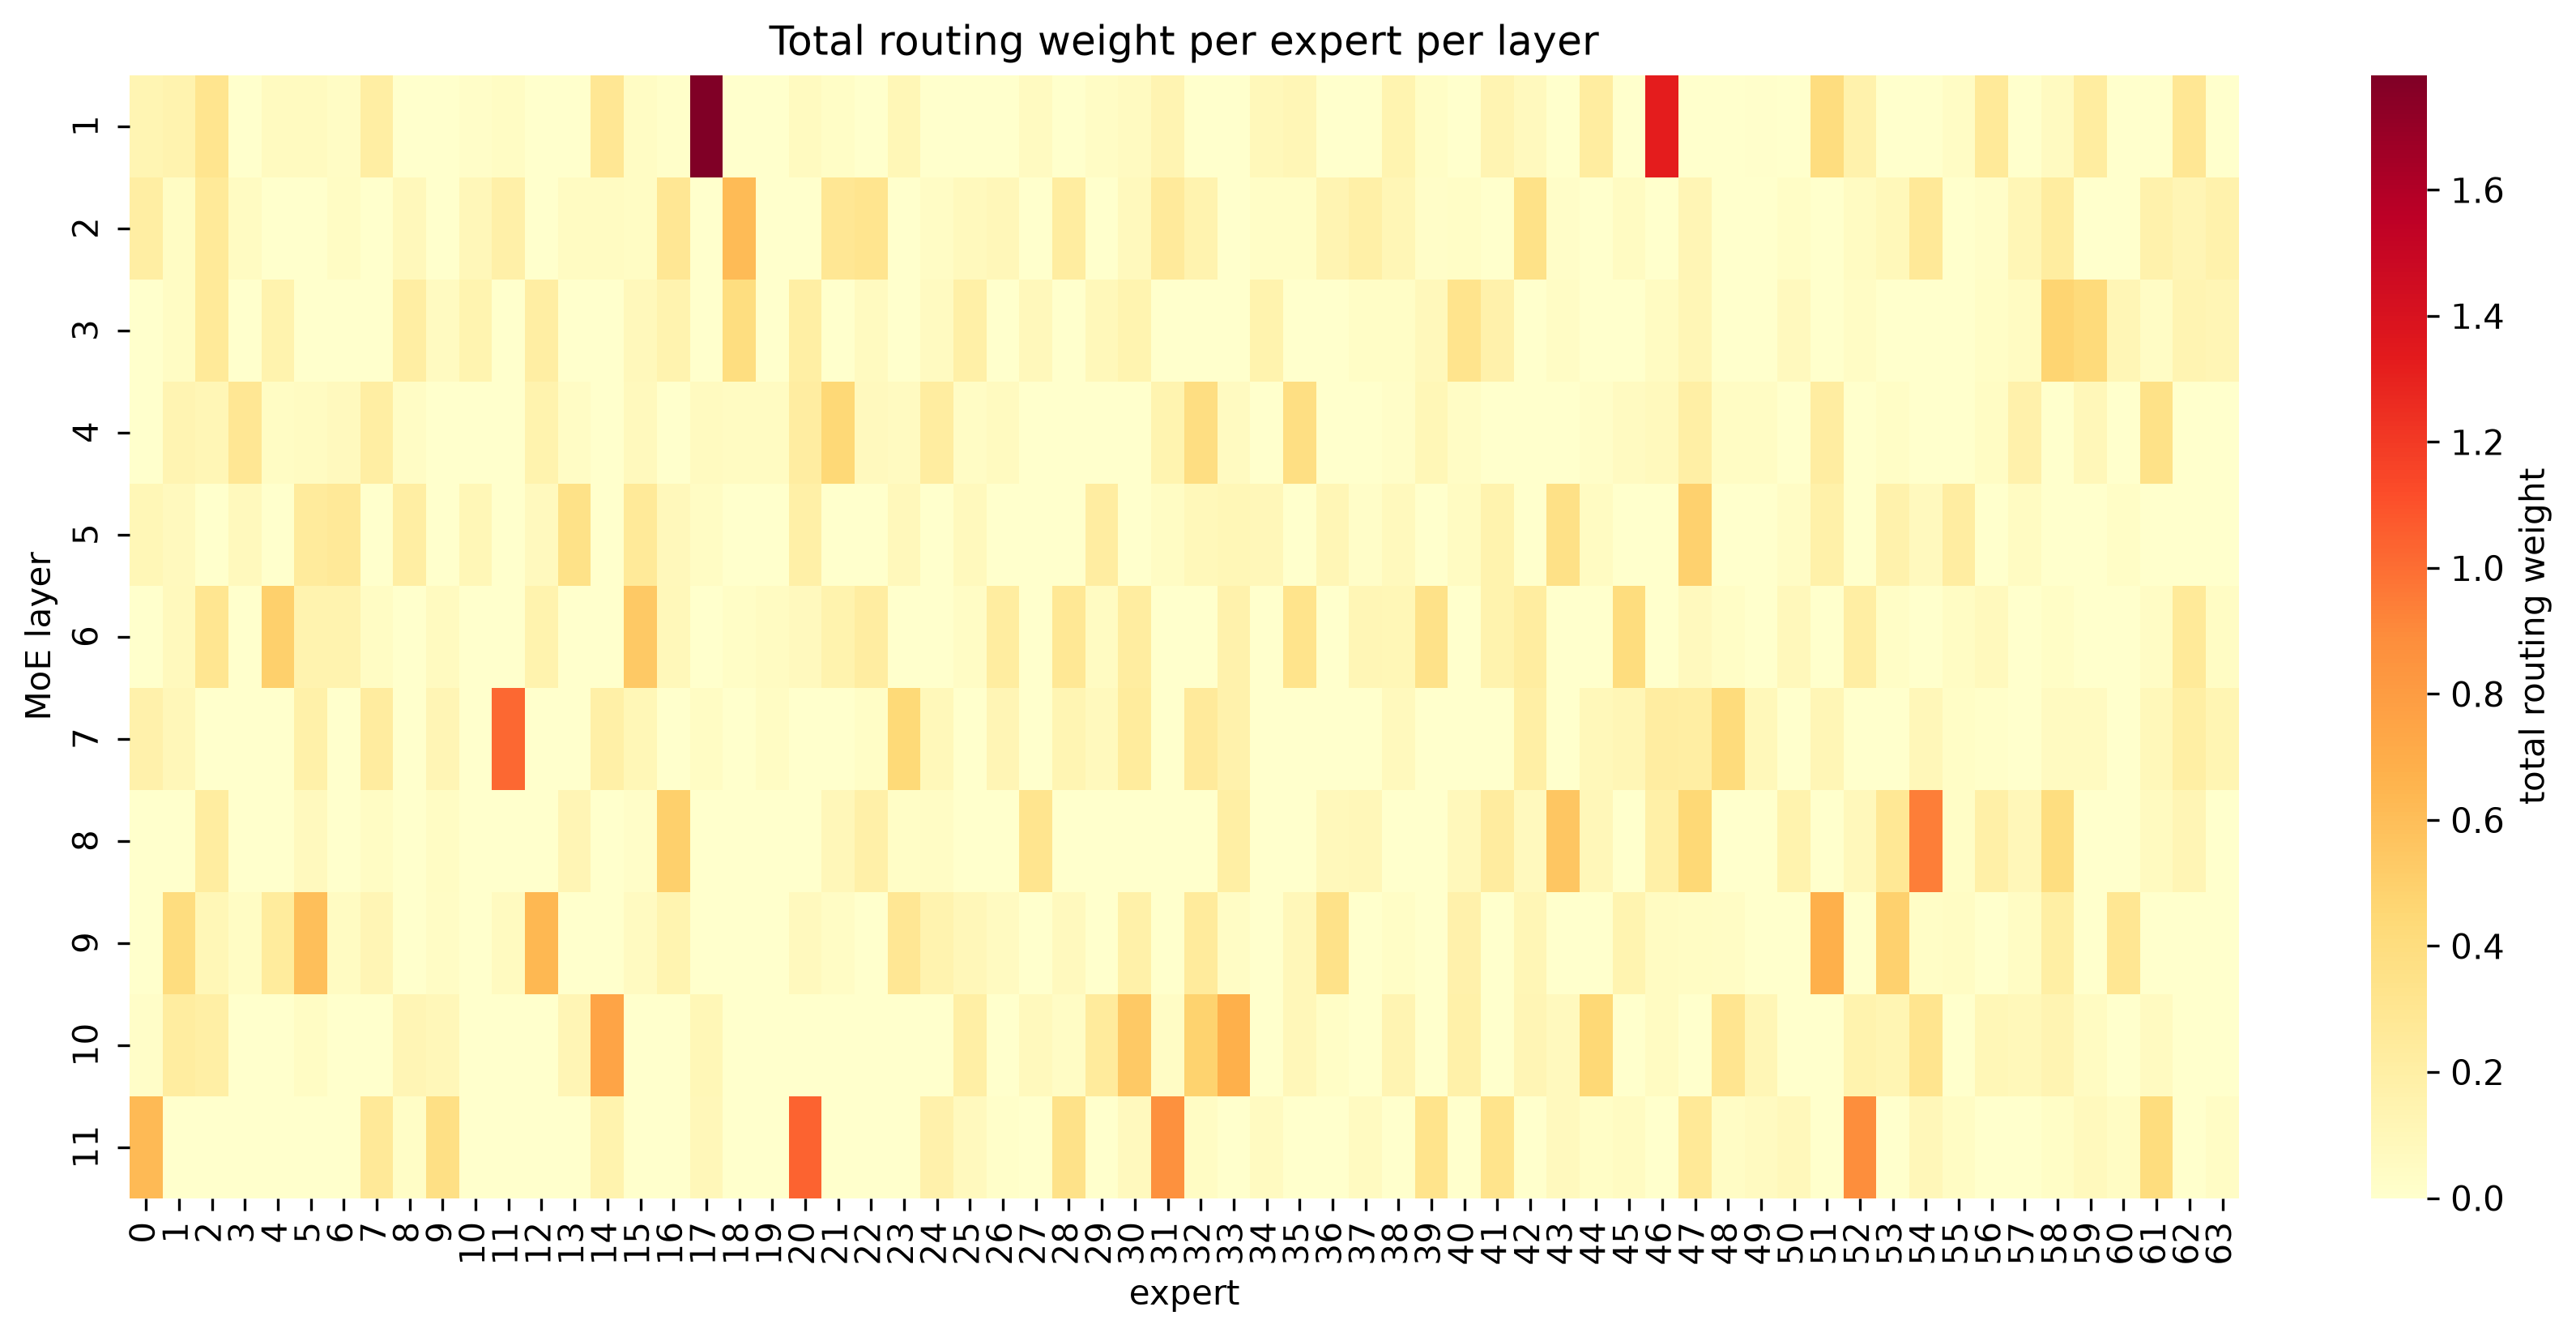

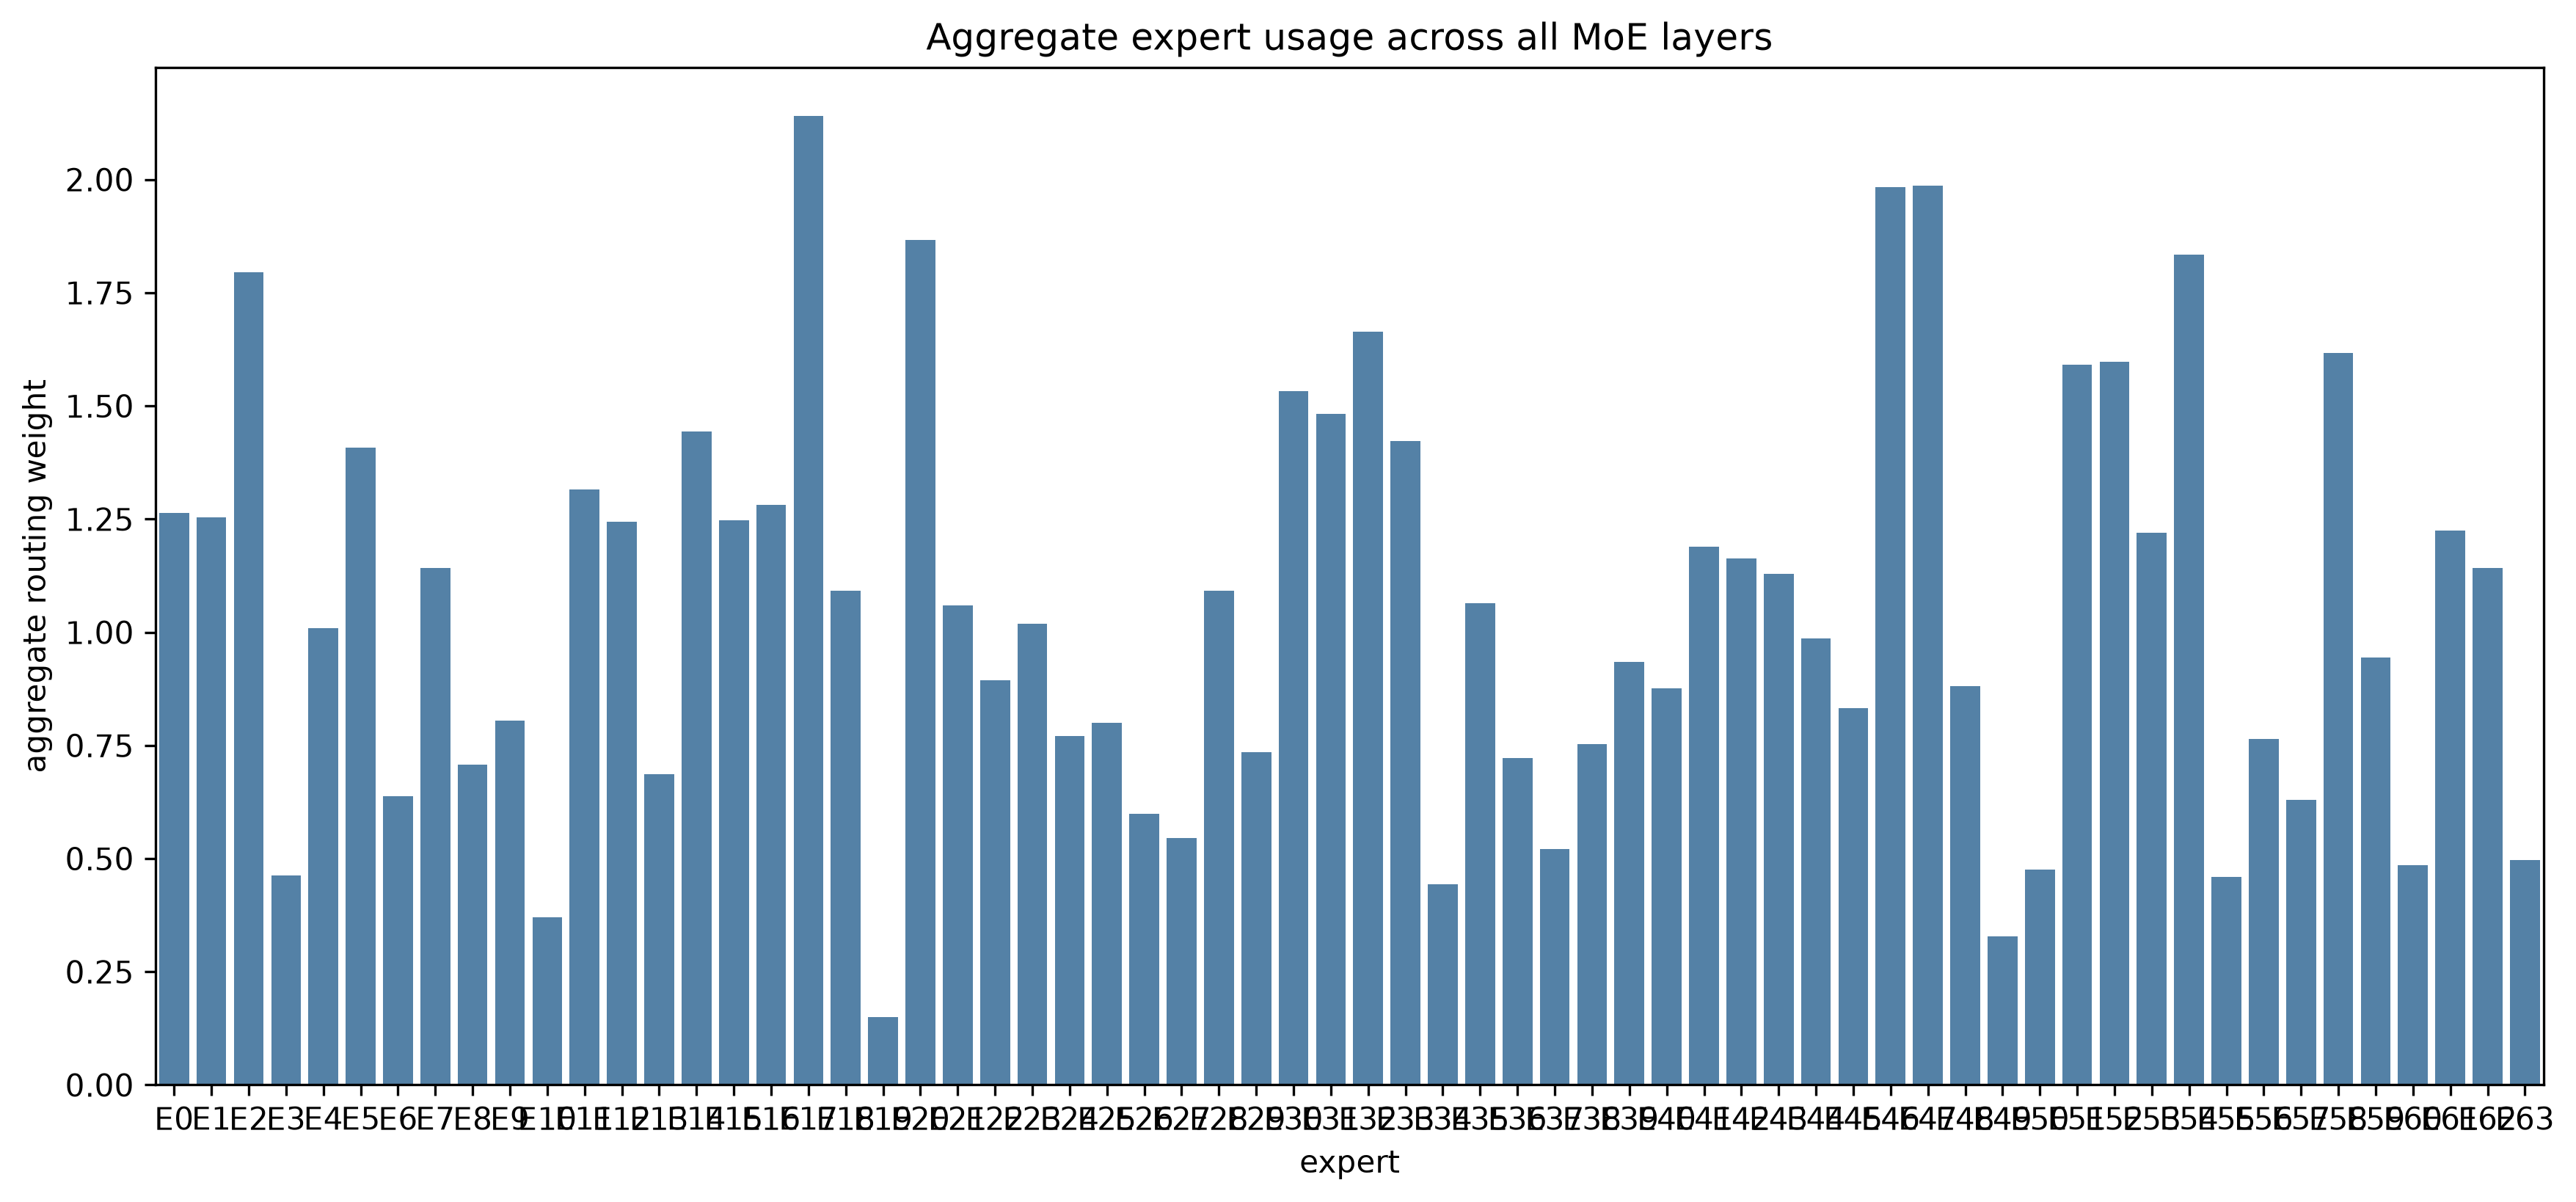

In [ ]:
try:
    for fname in (
        "01_gate_scores.png",
        "02_topk_selections.png",
        "03_expert_load.png",
        "04_aggregate_usage.png",
    ):
        plot_path = CONFIG.out_dir / fname
        if plot_path.exists():
            display(IPImage(filename=str(plot_path)))
except Exception as exc:  # noqa: BLE001
    logger.info("Display skipped (not running in a notebook frontend): %s", exc)